In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.columns

Rows: 8469
Columns: 17


Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [ ]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [ ]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [ ]:
df = df.rename(columns={
    'Ticket Description': 'text',
    'Category': 'category',
    'Priority': 'priority'
})

In [ ]:
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# Rename actual column
df = df.rename(columns={
    'Ticket Description': 'text',
    'Ticket Priority': 'priority'
})

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nPriority Counts:")
print(df['priority'].value_counts())

print("\nSample Data:")
display(df[['text', 'priority']].head())

Saving customer_support_tickets.csv to customer_support_tickets.csv
Dataset loaded successfully!
Rows: 8469
Columns: 17

Priority Counts:
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Sample Data:


,text,priority
0,I'm having an issue with the {product_purchase...,Critical
1,I'm having an issue with the {product_purchase...,Critical
2,I'm facing a problem with my {product_purchase...,Low
3,I'm having an issue with the {product_purchase...,Low
4,I'm having an issue with the {product_purchase...,Low


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK stopwords
nltk.download('stopwords')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# Clean ticket descriptions
df['clean_text'] = df['text'].apply(clean_text)

# Check result
display(df[['text', 'clean_text']].head())

,text,clean_text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


In [ ]:
def assign_category(text):
    text = str(text).lower()

    if any(word in text for word in [
        'payment', 'billing', 'refund', 'charge', 'invoice', 'price'
    ]):
        return 'Billing'

    elif any(word in text for word in [
        'login', 'password', 'account', 'username', 'access', 'signin'
    ]):
        return 'Account'

    elif any(word in text for word in [
        'error', 'bug', 'technical', 'crash', 'not working', 'issue'
    ]):
        return 'Technical Issue'

In [ ]:
# Create category from ticket text

def assign_category(text):
    text = str(text).lower()

    if any(word in text for word in [
        'payment', 'billing', 'refund', 'charge', 'invoice', 'price'
    ]):
        return 'Billing'

    elif any(word in text for word in [
        'login', 'password', 'account', 'username', 'access', 'signin'
    ]):
        return 'Account'

    elif any(word in text for word in [
        'error', 'bug', 'technical', 'crash', 'not working', 'issue'
    ]):
        return 'Technical Issue'

    else:
        return 'General Query'


# Create category column
df['category'] = df['clean_text'].apply(assign_category)

# Check both target columns
print("===== CATEGORY COUNTS =====")
print(df['category'].value_counts())

print("\n===== PRIORITY COUNTS =====")
print(df['priority'].value_counts())

print("\n===== SAMPLE DATA =====")
display(
    df[['text', 'clean_text', 'category', 'priority']].head(10)
)

===== CATEGORY COUNTS =====
category
Technical Issue    6554
Billing             850
Account             756
General Query       309
Name: count, dtype: int64

===== PRIORITY COUNTS =====
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

===== SAMPLE DATA =====


,text,clean_text,category,priority
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...,Billing,Critical
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...,Technical Issue,Critical
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...,Billing,Low
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...,Technical Issue,Low
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...,Technical Issue,Low
5,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...,General Query,Low
6,I'm unable to access my {product_purchased} ac...,im unable access productpurchased account keep...,Account,Critical
7,I'm having an issue with the {product_purchase...,im issue productpurchased please assist thanks...,Technical Issue,Critical
8,I'm having an issue with the {product_purchase...,im issue productpurchased please assist thank ...,Technical Issue,Low
9,My {product_purchased} is making strange noise...,productpurchased making strange noises functio...,Technical Issue,Critical


In [ ]:
# Input and target
X = df['clean_text']
y = df['category']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Category Prediction Data Split")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Category Prediction Data Split
Training samples: 6775
Testing samples: 1694


In [ ]:
# Create TF-IDF vectorizer
category_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Learn vocabulary from training data
X_train_tfidf = category_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = category_vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training shape: (6775, 5000)
Testing shape: (1694, 5000)


In [ ]:
# Create Logistic Regression model
category_model = LogisticRegression(
    max_iter=1000
)

# Train the model
category_model.fit(
    X_train_tfidf,
    y_train
)

print("Category prediction model trained successfully!")

Category prediction model trained successfully!


In [ ]:
# Predict categories for test data
y_pred_category = category_model.predict(X_test_tfidf)

# Calculate accuracy
category_accuracy = accuracy_score(
    y_test,
    y_pred_category
)

print("Category Model Accuracy:")
print(f"{category_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_category
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_category
    )
)

Category Model Accuracy:
93.57%

Classification Report:
                 precision    recall  f1-score   support

        Account       0.97      0.72      0.83       151
        Billing       0.99      0.65      0.78       170
  General Query       0.92      0.92      0.92        62
Technical Issue       0.93      1.00      0.96      1311

       accuracy                           0.94      1694
      macro avg       0.95      0.82      0.87      1694
   weighted avg       0.94      0.94      0.93      1694


Confusion Matrix:
[[ 109    1    2   39]
 [   3  110    1   56]
 [   0    0   57    5]
 [   0    0    2 1309]]


In [ ]:
# Input and target for Priority Prediction

X_priority = df['clean_text']
y_priority = df['priority']

# Split into training and testing data
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_priority,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

print("Priority Prediction Data Split")
print("Training samples:", len(X_train_p))
print("Testing samples:", len(X_test_p))
print("\nPriority classes:")
print(y_priority.value_counts())

Priority Prediction Data Split
Training samples: 6775
Testing samples: 1694

Priority classes:
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [ ]:
# Create TF-IDF vectorizer for priority prediction

priority_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit on training data
X_train_priority_tfidf = priority_vectorizer.fit_transform(
    X_train_p
)

# Transform test data
X_test_priority_tfidf = priority_vectorizer.transform(
    X_test_p
)

print("Priority TF-IDF conversion completed!")
print("Training shape:", X_train_priority_tfidf.shape)
print("Testing shape:", X_test_priority_tfidf.shape)

Priority TF-IDF conversion completed!
Training shape: (6775, 5000)
Testing shape: (1694, 5000)


In [ ]:
# Create Priority Prediction Model

priority_model = LogisticRegression(
    max_iter=1000
)

# Train the model
priority_model.fit(
    X_train_priority_tfidf,
    y_train_p
)

print("Priority prediction model trained successfully!")

Priority prediction model trained successfully!


In [ ]:
# Predict priority for test data
y_pred_priority = priority_model.predict(
    X_test_priority_tfidf
)

# Calculate accuracy
priority_accuracy = accuracy_score(
    y_test_p,
    y_pred_priority
)

print("Priority Model Accuracy:")
print(f"{priority_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_p,
        y_pred_priority
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_p,
        y_pred_priority
    )
)

Priority Model Accuracy:
25.38%

Classification Report:
              precision    recall  f1-score   support

    Critical       0.23      0.22      0.22       426
        High       0.26      0.24      0.25       417
         Low       0.24      0.24      0.24       413
      Medium       0.28      0.31      0.29       438

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694


Confusion Matrix:
[[ 92 101 121 112]
 [100 102 101 114]
 [ 99  92 101 121]
 [108  97  98 135]]


In [ ]:
# New customer ticket
new_ticket = """
My payment failed and I cannot access my account.
Please help me resolve this issue.
"""

# Clean the new ticket
clean_ticket = clean_text(new_ticket)

# Convert text into TF-IDF for category model
category_features = category_vectorizer.transform(
    [clean_ticket]
)

# Predict category
predicted_category = category_model.predict(
    category_features
)[0]

# Convert text into TF-IDF for priority model
priority_features = priority_vectorizer.transform(
    [clean_ticket]
)

# Predict priority
predicted_priority = priority_model.predict(
    priority_features
)[0]

print("NEW CUSTOMER TICKET")
print("-------------------")
print(new_ticket)

print("\nPredicted Category:", predicted_category)
print("Predicted Priority:", predicted_priority)

NEW CUSTOMER TICKET
-------------------

My payment failed and I cannot access my account.
Please help me resolve this issue.


Predicted Category: Account
Predicted Priority: Medium


In [ ]:
def predict_ticket(ticket_text):

    # Clean text
    cleaned = clean_text(ticket_text)

    # Category prediction
    category_features = category_vectorizer.transform([cleaned])
    predicted_category = category_model.predict(
        category_features
    )[0]

    # Priority prediction
    priority_features = priority_vectorizer.transform([cleaned])
    predicted_priority = priority_model.predict(
        priority_features
    )[0]

    return predicted_category, predicted_priority


# Test the function
ticket = "I was charged twice for my payment. Please refund the extra amount."

category, priority = predict_ticket(ticket)

print("Customer Ticket:")
print(ticket)

print("\nPredicted Category:", category)
print("Predicted Priority:", priority)

Customer Ticket:
I was charged twice for my payment. Please refund the extra amount.

Predicted Category: Billing
Predicted Priority: Critical


In [ ]:
# Multiple test tickets

test_tickets = [
    "My payment failed and I was charged twice.",
    "I forgot my password and cannot login to my account.",
    "The application shows an error and is not working.",
    "I want to know more about your product."
]

for i, ticket in enumerate(test_tickets, start=1):

    category, priority = predict_ticket(ticket)

    print(f"\nTicket {i}")
    print("-" * 40)
    print("Ticket:", ticket)
    print("Predicted Category:", category)
    print("Predicted Priority:", priority)


Ticket 1
----------------------------------------
Ticket: My payment failed and I was charged twice.
Predicted Category: Billing
Predicted Priority: Critical

Ticket 2
----------------------------------------
Ticket: I forgot my password and cannot login to my account.
Predicted Category: Account
Predicted Priority: High

Ticket 3
----------------------------------------
Ticket: The application shows an error and is not working.
Predicted Category: Technical Issue
Predicted Priority: Critical

Ticket 4
----------------------------------------
Ticket: I want to know more about your product.
Predicted Category: Technical Issue
Predicted Priority: High


In [ ]:
# Create prediction results table

prediction_results = []

for ticket in test_tickets:

    category, priority = predict_ticket(ticket)

    prediction_results.append({
        "Ticket": ticket,
        "Predicted Category": category,
        "Predicted Priority": priority
    })

prediction_df = pd.DataFrame(prediction_results)

print("FINAL PREDICTION RESULTS")
display(prediction_df)

FINAL PREDICTION RESULTS


,Ticket,Predicted Category,Predicted Priority
0,My payment failed and I was charged twice.,Billing,Critical
1,I forgot my password and cannot login to my ac...,Account,High
2,The application shows an error and is not work...,Technical Issue,Critical
3,I want to know more about your product.,Technical Issue,High


In [ ]:
# Save prediction results

prediction_df.to_csv(
    "ticket_prediction_results.csv",
    index=False
)

print("Prediction results saved successfully!")
print("File: ticket_prediction_results.csv")

Prediction results saved successfully!
File: ticket_prediction_results.csv


In [ ]:
# Model performance summary

performance_df = pd.DataFrame({
    "Model": [
        "Category Prediction",
        "Priority Prediction"
    ],
    "Accuracy (%)": [
        round(category_accuracy * 100, 2),
        round(priority_accuracy * 100, 2)
    ]
})

print("MODEL PERFORMANCE SUMMARY")
display(performance_df)

MODEL PERFORMANCE SUMMARY


,Model,Accuracy (%)
0,Category Prediction,93.57
1,Priority Prediction,25.38


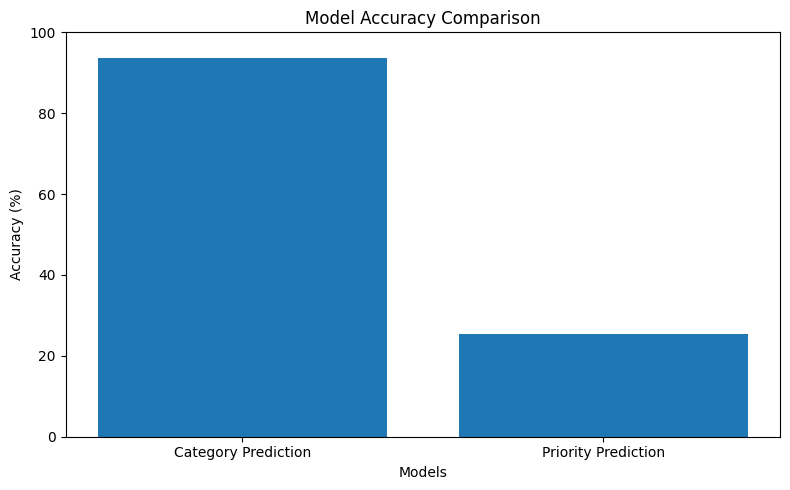

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    performance_df["Model"],
    performance_df["Accuracy (%)"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)
plt.tight_layout()

# Save graph
plt.savefig("model_accuracy.png")

plt.show()